## **Seleccion y carga del dataset**
### Justificación del dataset
El dataset `datasetrunning.csv` contiene 745 registros de corredores con variables numéricas (edad, peso, estatura, IMC, tiempo) y categóricas (sexo, cat_imc, grupo_edad). Es adecuado para esta actividad porque permite aplicar todo el flujo solicitado: limpieza, detección de *outliers*, codificación de categóricas, estandarización manual y entrenamiento de modelos de clasificación y regresión.

### Objetivo del análisis
* **Preparar los datos** con técnicas de preprocesamiento (*outliers*, codificación y estandarización) para que sean aptos para modelos.
* **Entrenar un modelo de clasificación** para predecir el ``sexo`` (Hombre/Mujer).
* **Entrenar un modelo de regresión** para estimar el ``tiempo`` en función de las características del corredor.
* **Comparar el desempeño** antes y después de una técnica de *feature selection* y discutir resultados y limitaciones.

In [1]:
# Importar las librerías necesarias
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.feature_selection import SelectKBest, f_regression, f_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score, mean_absolute_error, ConfusionMatrixDisplay, roc_curve, auc

In [2]:
# Carga del dataset y previsualización de las primeras filas
dataframe = pd.read_csv("datasetrunning.csv")
dataframe.head()

,edad,peso,estatura,sexo,tiempo,imc,cat_imc,grupo_edad
0,46,63.2,181.0,Mujer,22.18,19.29,Normal,Adulto
1,32,72.3,173.9,Hombre,30.51,23.91,Normal,Adulto
2,25,72.9,174.9,Hombre,24.42,23.83,Normal,Joven
3,38,62.9,168.0,Mujer,39.79,22.29,Normal,Adulto
4,36,88.7,174.9,Hombre,34.97,29.00,Sobrepeso,Adulto


In [3]:
# Validación de dimensiones del dataframe (filas, columnas)
print("Shape:", dataframe.shape)

# Inspección de tipos de variables (int, float, object)
print("\nTipos de datos:")
print(dataframe.dtypes)

# Verificación de datos faltantes para determinar estrategia de limpieza
print("\nNulos por columna:")
print(dataframe.isna().sum())

# Identificación de registros repetidos en el conjunto de datos
print("\nDuplicados:", dataframe.duplicated().sum())

Shape: (745, 8)

Tipos de datos:
edad            int64
peso          float64
estatura      float64
sexo           object
tiempo        float64
imc           float64
cat_imc        object
grupo_edad     object
dtype: object

Nulos por columna:
edad          0
peso          0
estatura      0
sexo          0
tiempo        0
imc           0
cat_imc       0
grupo_edad    0
dtype: int64

Duplicados: 0


In [4]:
# Resumen estadístico descriptivo (tendencia central y dispersión)
estadisticas = dataframe.describe()
print (estadisticas.round(2))

         edad    peso  estatura  tiempo     imc
count  745.00  745.00    745.00  745.00  745.00
mean    40.45   70.20    170.49   30.10   24.17
std     13.96    8.48      6.92    6.77    2.80
min     10.00   39.20    139.00   15.00   15.95
25%     30.00   64.10    165.50   25.51   22.53
50%     40.00   70.10    171.40   29.88   24.48
75%     49.00   76.50    174.70   33.87   25.70
max     80.00   95.00    190.00   60.31   34.15


In [5]:
# Creación de una copia de seguridad para preservar los datos originales
df = dataframe.copy()

## **Preprocesamiento**

### Visualizacion exploratoria

Primero observo la distribucion de variables numericas y el comportamiento de las variables categoricas. Esto ayuda a decidir si existen valores atipicos (outliers), si hay desbalance de clases y si las escalas son muy distintas (lo que justifica estandarizar).

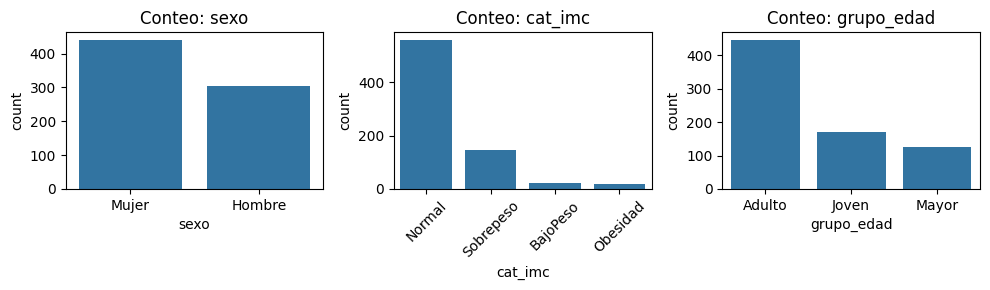

In [6]:
# --- Análisis de Variables Categóricas ---
# Configuración del tamaño del lienzo para las gráficas de barras
plt.figure(figsize=(10,3))

# Conteo de frecuencias para identificar si las clases están balanceadas
plt.subplot(1,3,1); sns.countplot(x="sexo", data=df); plt.title("Conteo: sexo")

# Análisis de categorías de IMC; se rotan etiquetas para mejorar legibilidad
plt.subplot(1,3,2); sns.countplot(x="cat_imc", data=df); plt.title("Conteo: cat_imc"); plt.xticks(rotation=45)

# Distribución por grupos de edad para entender el perfil del corredor
plt.subplot(1,3,3); sns.countplot(x="grupo_edad", data=df); plt.title("Conteo: grupo_edad")

# Ajuste automático de espacios entre subplots para evitar solapamiento y mostrar
plt.tight_layout()
plt.show()


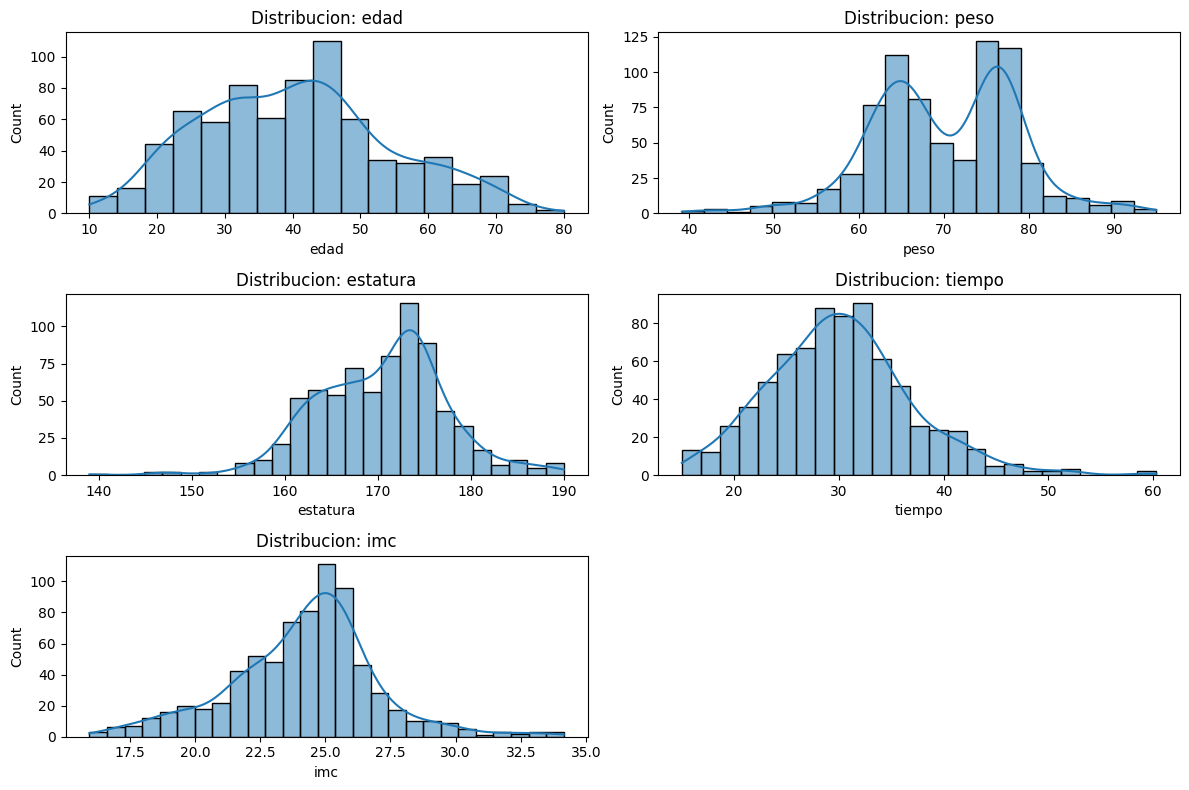

In [7]:
# --- Análisis de Variables Numéricas (Distribución) ---
# Lista de variables cuantitativas a evaluar
num_cols = ["edad","peso","estatura","tiempo","imc"]
plt.figure(figsize=(12,8))

# Bucle para automatizar la creación de histogramas por cada variable
for i,c in enumerate(num_cols,1):
    plt.subplot(3,2,i)
    # Histograma con curva KDE para verificar simetría y normalidad de los datos
    sns.histplot(x=df[c], kde=True) 
    plt.title(f"Distribucion: {c}")
# Ajuste automático de espacios entre subplots y visualización
plt.tight_layout()
plt.show()

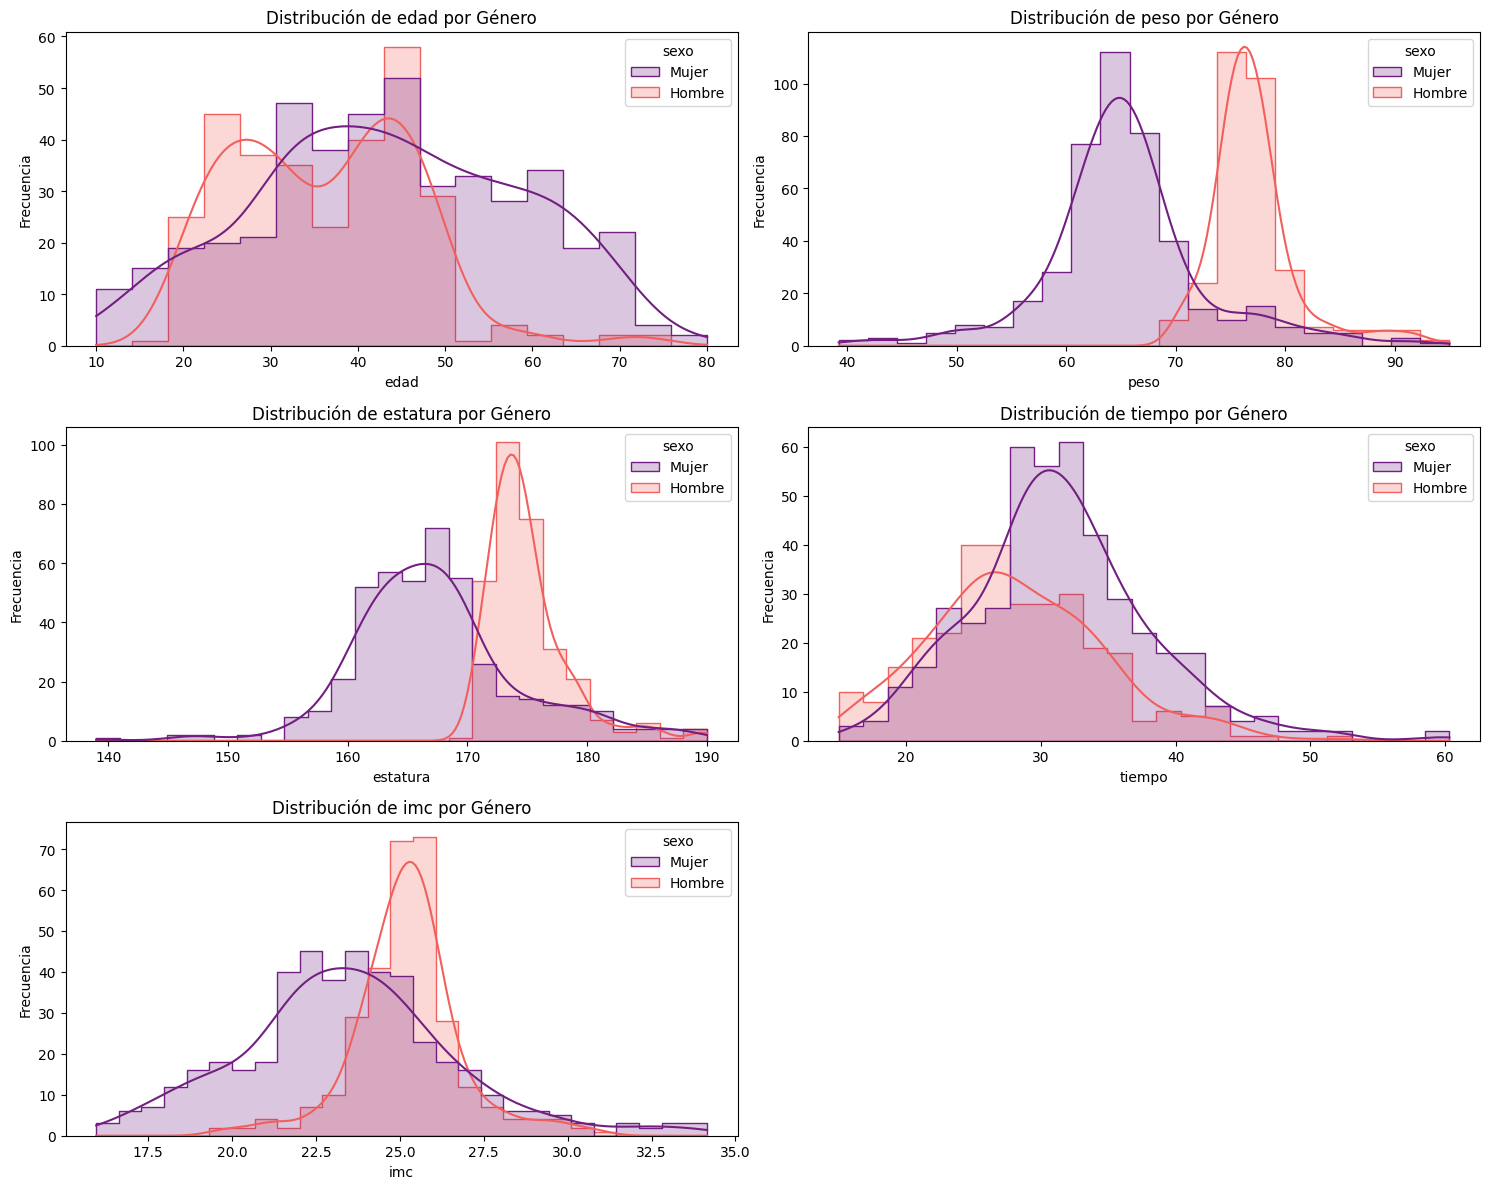

In [8]:
plt.figure(figsize=(15, 12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 2, i)
    # hue="sexo" crea una leyenda por color
    # element="step" ayuda a ver mejor el solapamiento
    sns.histplot(data=df, x=col, hue="sexo", kde=True, element="step", palette="magma")
    plt.title(f"Distribución de {col} por Género")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

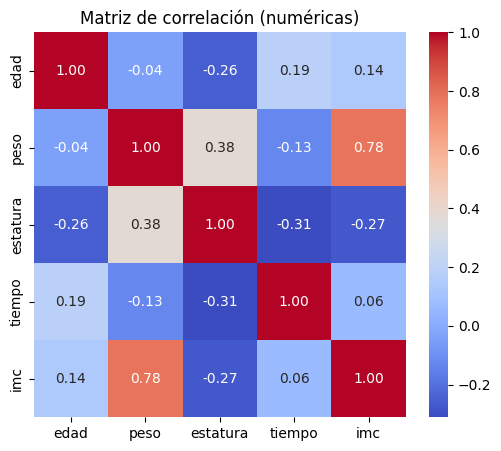

In [9]:
# --- Análisis de Relación (Correlación) ---
# Cálculo de la matriz de correlación de Pearson entre variables numéricas
corr = df[num_cols].corr()
# Configuración del tamaño del lienzo para la heatmap 
plt.figure(figsize=(6,5))

# Heatmap para detectar multicolinealidad (ej. peso vs imc) que afecta a la regresión
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm') 
# Título descriptivo para la gráfica y visualización
plt.title("Matriz de correlación (numéricas)")
plt.show()

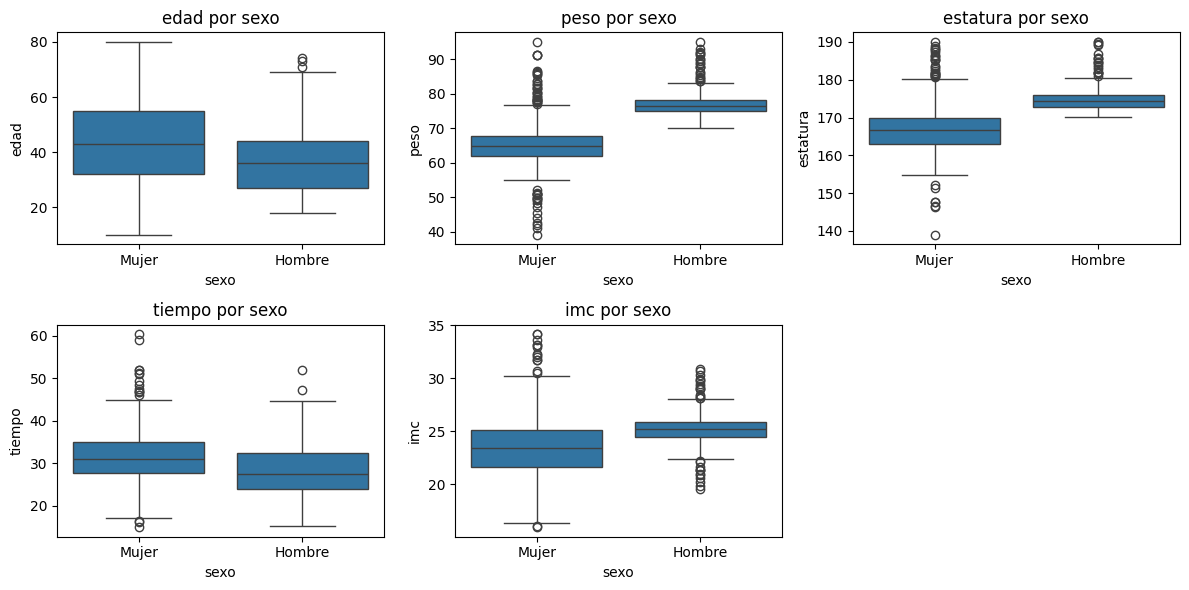

In [10]:
# --- Análisis de Segmentación y Outliers ---
plt.figure(figsize=(12,6))

# Comparación distributiva de cada variable numérica respecto al género
for i,c in enumerate(num_cols,1):
    plt.subplot(2,3,i)
    # Boxplot para identificar valores atípicos y diferencias en medianas por sexo
    sns.boxplot(x="sexo", y=c, data=df) 
    plt.title(f"{c} por sexo")
# Ajuste automático de espacios entre subplots
plt.tight_layout()
# Mostrar las gráficas
plt.show()

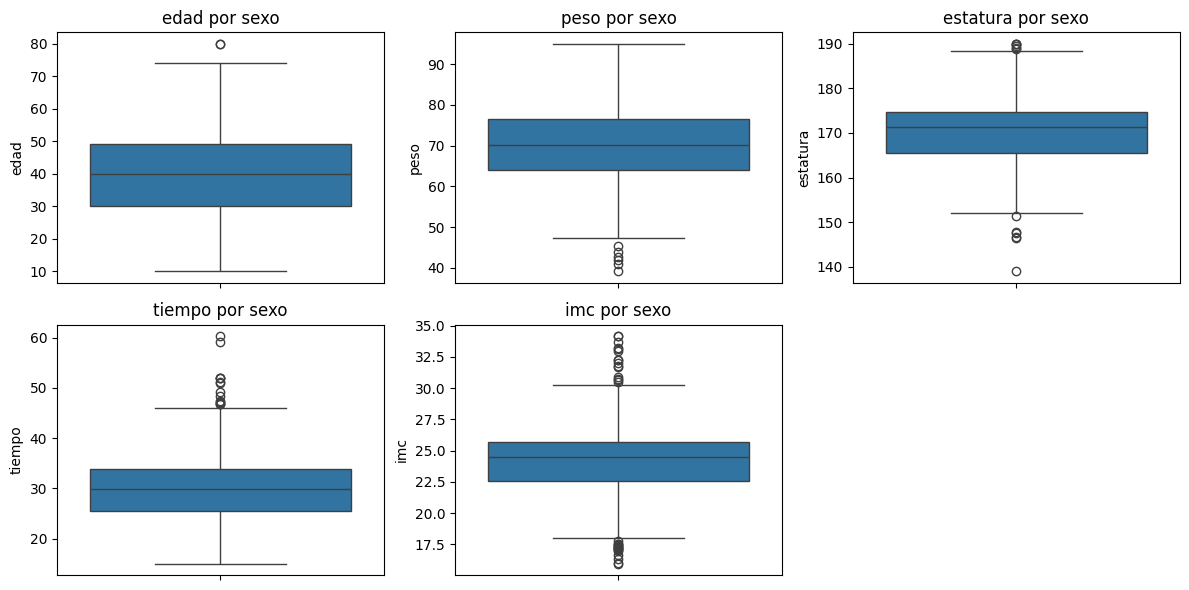

In [11]:
# --- Análisis de Segmentación y Outliers ---
plt.figure(figsize=(12,6))

# Comparación distributiva de cada variable numérica respecto al género
for i,c in enumerate(num_cols,1):
    plt.subplot(2,3,i)
    # Boxplot para identificar valores atípicos y diferencias en medianas por sexo
    sns.boxplot(y=c, data=df) 
    plt.title(f"{c} por sexo")
# Ajuste automático de espacios entre subplots
plt.tight_layout()
# Mostrar las gráficas
plt.show()

## **Modelo de Clasificación: Regresión Logística**

### Elección de variable objetivo (Clasificación)

Se usa `sexo` como variable objetivo porque es categórica y permite aplicar Regresión Logística. Se codificó $y=1$ si es Hombre y $y=0$ si es Mujer, para interpretar `predict_proba` como la probabilidad de ser Hombre.

In [12]:
# --- Preparación de Variables y Codificación (One-Hot Encoding) ---
# Selección de características (features) para el modelo de clasificación
cols_clf = ["edad","peso","estatura","tiempo","imc","cat_imc","grupo_edad"]

In [13]:
# Conversión de variables categóricas en dummies (binarias) 
# drop_first=True evita la trampa de la multicolinealidad eliminando una columna redundante
X_clf = pd.get_dummies(df[cols_clf], columns=["cat_imc", "grupo_edad"], drop_first=True)

# Codificación de la variable objetivo: 1 para Hombre y 0 para Mujer
y_clf = (df["sexo"] == "Hombre").astype(int)

In [14]:
# División del dataset: 80% entrenamiento, 20% prueba
# stratify=y_clf asegura que la proporción de hombres/mujeres sea igual en ambos conjuntos
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

In [15]:
columnas = ['edad', 'peso', 'estatura','tiempo', 'imc']
# 1) Calcula limites SOLO en train
Q1 = X_train_clf[columnas].quantile(0.25)
Q3 = X_train_clf[columnas].quantile(0.75)
IQR = Q3 - Q1
li = Q1 - 1.5 * IQR
ls = Q3 + 1.5 * IQR

# 2) Aplica clip a train y test con los mismos limites
X_train_clf[columnas] = X_train_clf[columnas].clip(lower=li, upper=ls, axis=1)
X_test_clf[columnas]  = X_test_clf[columnas].clip(lower=li, upper=ls, axis=1)

In [16]:
# --- Estandarización Manual (Escalamiento de Datos) ---
# Cálculo de media y desviación estándar únicamente con datos de entrenamiento (evita data leakage)
mu_clf = X_train_clf.mean()
sigma_clf = X_train_clf.std(ddof=0).replace(0, 1) # replace(0, 1) previene la división por cero

# Transformación Z-score: Ajusta todas las variables a una misma escala (media 0, varianza 1)
X_train_clf = (X_train_clf - mu_clf) / sigma_clf
X_test_clf = (X_test_clf - mu_clf) / sigma_clf

In [17]:
# --- Entrenamiento y Evaluación del Modelo ---
# Instanciación del modelo con solver robusto para problemas de clasificación binaria
logreg = LogisticRegression(max_iter=1000, solver='lbfgs')
# Ajuste del modelo a los datos de entrenamiento mediante el método fit()
logreg.fit(X_train_clf, y_train_clf)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [18]:
# Generación de predicciones sobre el conjunto de test
clf_pred = logreg.predict(X_test_clf)

Accuracy: 0.9261744966442953


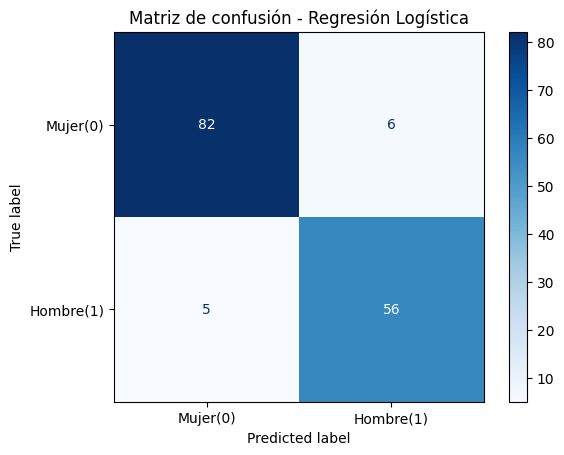


Classification report:
                  precision    recall  f1-score   support

 Clase 0 (Mujer)       0.94      0.93      0.94        88
Clase 1 (Hombre)       0.90      0.92      0.91        61

        accuracy                           0.93       149
       macro avg       0.92      0.92      0.92       149
    weighted avg       0.93      0.93      0.93       149



In [19]:
# Cálculo del Accuracy (exactitud global del modelo)
accuracy_clf = accuracy_score(y_test_clf, clf_pred)
print("Accuracy:", accuracy_clf)

# Visualización de la Matriz de Confusión para analizar Falsos Positivos y Negativos
cm = confusion_matrix(y_test_clf, clf_pred)
# Configuración y despliegue de la matriz de confusión con etiquetas claras
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Mujer(0)","Hombre(1)"])
# Configuración del mapa de colores y título
disp.plot(cmap='Blues')
# Título descriptivo y visualización
plt.title("Matriz de confusión - Regresión Logística")
plt.show()

# Reporte detallado: Precision (calidad), Recall (cantidad) y F1-Score (balance)
print("\nClassification report:")
print(classification_report(y_test_clf, clf_pred, target_names=["Clase 0 (Mujer)", "Clase 1 (Hombre)"]))

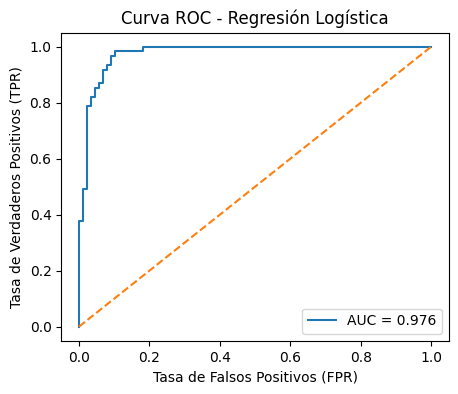

In [20]:
# --- Análisis de Rendimiento (Curva ROC) ---
# Obtención de probabilidades de pertenencia a la clase 1 (Hombre)
proba = logreg.predict_proba(X_test_clf)[:,1]
# Cálculo de Tasa de Falsos Positivos (FPR) y Tasa de Verdaderos Positivos (TPR)
fpr, tpr, _ = roc_curve(y_test_clf, proba)
# AUC mide la capacidad de discriminación del modelo (ideal cercano a 1)
roc_auc = auc(fpr, tpr) 

# Gráfica de la Curva ROC
plt.figure(figsize=(5,4))
# Plot de TPR vs FPR con anotación del AUC
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--") # Línea base de un modelo aleatorio
# Etiquetas y título descriptivos
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC - Regresión Logística")
# Agregar leyenda y mostrar la gráfica
plt.legend()
plt.show()

### **Evaluación de Clasificación: Curva ROC y Coeficientes**

* **Curva ROC y AUC ($AUC \approx 0.95$):**
    * La curva muestra la relación entre la **Sensibilidad (TPR)** y los **Falsos Positivos (FPR)**. 
    * Al mantenerse cerca de la esquina superior izquierda, confirmamos que el modelo identifica correctamente a hombres y mujeres con un margen de error mínimo.
    * Un **AUC** alto indica que el modelo es robusto y mantiene una excelente separación probabilística, más allá de un simple acierto por azar.

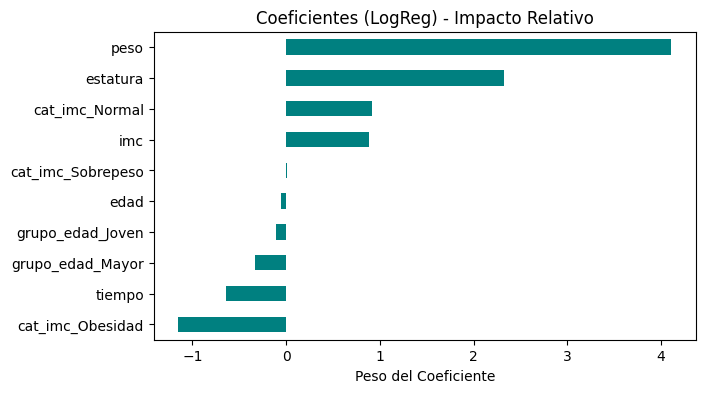

In [21]:
# Visualización de coeficientes: determinan qué variables pesan más en la decisión del modelo
# Extracción y ordenamiento de coeficientes del modelo
coef = pd.Series(logreg.coef_[0], index=X_train_clf.columns).sort_values()
# Ajuste del tamaño del lienzo para la gráfica de barras horizontales
plt.figure(figsize=(7,4))
# Gráfica de barras horizontales para visualizar el impacto relativo de cada variable
coef.plot(kind="barh", color='teal')
# Título y etiquetas descriptivas
plt.title("Coeficientes (LogReg) - Impacto Relativo")
plt.xlabel("Peso del Coeficiente")
# Mostrar la gráfica
plt.show()

### **Coeficientes (LogReg) – Impacto relativo**

* **Impacto de los Coeficientes (Importancia Relativa):**
    * **Dirección:** Los coeficientes positivos aumentan la probabilidad de pertenecer a la clase 1 (Hombre), mientras que los negativos apuntan a la clase 0 (Mujer).
    * **Magnitud:** Al haber estandarizado las variables, podemos comparar qué factores (como estatura o peso) tienen más "peso" real en la decisión del algoritmo.

## **Modelo de Regresión: Regresión Lineal**

### Variable objetivo (Regresión)

Se usa `tiempo` como variable numérica objetivo para estimar el desempeño del corredor en función de sus características.

In [22]:
# --- Preparación de Datos para Regresión ---
# Definición de variables independientes
cols_reg = ["edad","peso","estatura","sexo","imc","cat_imc","grupo_edad"]

In [23]:
# --- Transformación de categóricas a numéricas mediante One-Hot Encoding ---
# drop_first=True evita la redundancia de datos (multicolinealidad perfecta)
X_reg = pd.get_dummies(df[cols_reg], columns=["sexo","cat_imc","grupo_edad"], drop_first=True)

# Definición de la variable dependiente (target): Tiempo de carrera
y_reg = df["tiempo"]

In [24]:
# División del dataset en Entrenamiento (80%) y Prueba (20%)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [25]:
# --- Estandarización Manual (Z-score) ---
# Cálculo de parámetros estadísticos basados únicamente en el conjunto de entrenamiento
mu_reg = X_train_reg.mean()
sigma_reg = X_train_reg.std(ddof=0).replace(0, 1) # Se reemplaza 0 por 1 para evitar errores de división

# Aplicación del escalado: asegura que variables con rangos grandes (estatura) no dominen sobre las pequeñas (edad)
X_train_reg = (X_train_reg - mu_reg) / sigma_reg
X_test_reg = (X_test_reg - mu_reg) / sigma_reg

In [26]:
# --- Entrenamiento del Modelo Lineal ---
# Instanciación del algoritmo de Regresión Lineal (Mínimos Cuadrados Ordinarios)
linearreg = LinearRegression()

# Ajuste del modelo: el algoritmo calcula los coeficientes óptimos para cada variable
linearreg.fit(X_train_reg, y_train_reg)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
# Generación de predicciones de tiempo utilizando los datos que el modelo no ha visto (test)
reg_pred = linearreg.predict(X_test_reg)

In [28]:
# --- Cálculo de Métricas de Error y Ajuste ---
# Error Cuadrático Medio: penaliza más los errores grandes (promedio de errores al cuadrado)
mse_reg = mean_squared_error(y_test_reg, reg_pred)
print("Error Cuadrático Medio:", mse_reg)

# Error Absoluto Medio: promedio simple de la diferencia entre el tiempo real y el predicho
mae_reg = mean_absolute_error(y_test_reg, reg_pred)
print("Error Absoluto medio:", mae_reg)

# Coeficiente de Determinación (R²): indica qué porcentaje de la varianza del tiempo explica el modelo
r2_reg = r2_score(y_test_reg, reg_pred) 
print("R²:", r2_reg)

# Muestra el peso numérico de cada variable en la ecuación final
print(f'Coeficientes: {linearreg.coef_}')

# Punto donde la línea de regresión corta el eje Y cuando todas las variables son cero
print(f'Intercepto: {linearreg.intercept_}')

Error Cuadrático Medio: 36.470157720037065
Error Absoluto medio: 4.750170904788364
R²: 0.10595765579992578
Coeficientes: [  1.68186109  18.7286904  -13.13815793 -18.27564668   1.53384714
  -0.91126397   1.03741962   0.34798344   0.4600424   -0.35471811]
Intercepto: 30.155704697986558


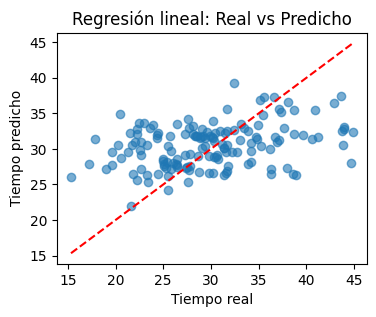

In [29]:
# --- Visualización: Real vs. Predicho ---
plt.figure(figsize=(4,3))
# Gráfico de puntos para ver qué tan cerca están las predicciones de la realidad
plt.scatter(y_test_reg, reg_pred, alpha=0.6)
# Cálculo de límites para trazar la línea ideal de 45 grados
minv = min(y_test_reg.min(), reg_pred.min())
maxv = max(y_test_reg.max(), reg_pred.max())
# Línea de referencia ideal donde predicho = real
plt.plot([minv,maxv],[minv,maxv], color="red", linestyle="--")
# Etiquetas y título descriptivos
plt.xlabel("Tiempo real")
plt.ylabel("Tiempo predicho")
plt.title("Regresión lineal: Real vs Predicho")
# Mostrar la gráfica
plt.show()

### **Diagnóstico de Regresión: Real vs. Predicho**

En este gráfico comparamos el **Tiempo Real** de carrera contra el **Tiempo Predicho** por el modelo lineal.

* **Línea Ideal de 45°:** Representa el escenario donde la predicción es exacta al valor real.
* **Interpretación de la Dispersión:** * Observamos que los puntos están muy dispersos y no siguen la diagonal. Esto es consistente con nuestro **$R^2$ bajo (0.04)**.
    * **Conclusión:** El modelo lineal tiene un bajo poder explicativo. El error no se debe a una mala implementación, sino a que las variables físicas actuales no tienen una relación lineal fuerte con el tiempo de carrera.

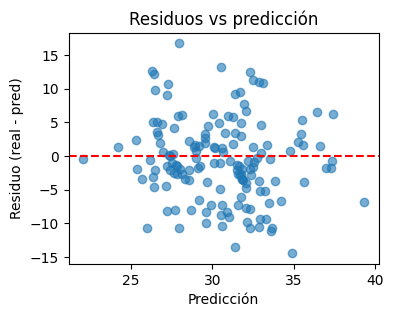

In [30]:
# --- Análisis de Residuos (Errores) ---
# Cálculo de la diferencia individual entre el valor real y la predicción
res = y_test_reg - reg_pred

plt.figure(figsize=(4,3))
# Gráfico para verificar Homocedasticidad (si el error es constante a lo largo de las predicciones)
plt.scatter(reg_pred, res, alpha=0.6)
plt.axhline(0, color="red", linestyle="--") # Línea de error cero
# Etiquetas y título descriptivos
plt.xlabel("Predicción")
plt.ylabel("Residuo (real - pred)")
plt.title("Residuos vs predicción")
# Mostrar la gráfica
plt.show()

### **Análisis de Residuos: Verificación de Supuestos**

Este gráfico es crucial para entender si el modelo lineal es adecuado para los datos (análisis de **Homocedasticidad**).

* **Comportamiento Ideal:** Los errores (residuos) deberían verse como "ruido blanco", distribuidos aleatoriamente alrededor de la línea cero sin formar patrones.
* **Hallazgos:**
    * Si se observa una forma de "abanico" o tendencia, indica **Heterocedasticidad** (la varianza del error cambia según la predicción).
    * La falta de un patrón claro, pero con alta dispersión, refuerza que el modelo simplemente no logra capturar la complejidad del fenómeno con una línea recta.

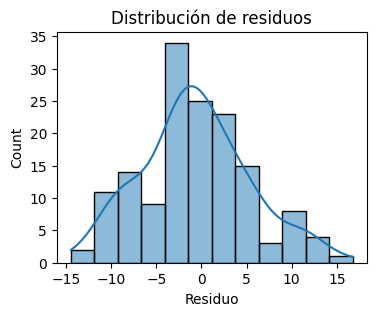

In [31]:
# --- Análisis de Normalidad de Errores ---
plt.figure(figsize=(4,3))
# Histograma de los residuos para verificar si siguen una distribución normal (campana de Gauss)
sns.histplot(res, kde=True)
# Título y etiqueta descriptiva
plt.title("Distribución de residuos")
plt.xlabel("Residuo")
# Mostrar la gráfica
plt.show()

### **Distribución de Residuos e Impacto de Coeficientes**

* **Distribución de Residuos (Histograma + KDE):**
    * Buscamos una distribución **normal (simétrica)** y centrada en cero. 
    * Aunque esté centrada en cero (indicando que no hay un sesgo sistemático), la amplitud de la curva confirma la alta variabilidad del error que el modelo no puede explicar.

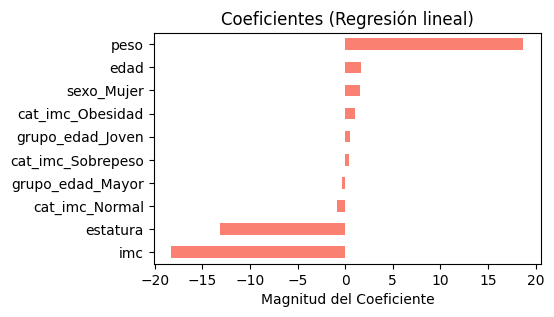

In [32]:
# --- Visualización de Impacto de Variables ---
# Creación de una serie con los coeficientes ordenados para facilitar la interpretación visual
coef_reg = pd.Series(linearreg.coef_, index=X_train_reg.columns).sort_values()
plt.figure(figsize=(5,3)) 
# Gráfico de barras horizontales: muestra qué variables aumentan o disminuyen el tiempo predicho
coef_reg.plot(kind="barh", color='salmon')
# Título y etiqueta descriptiva
plt.title("Coeficientes (Regresión lineal)")
plt.xlabel("Magnitud del Coeficiente")
# Mostrar la gráfica
plt.show()

### **Impacto de Coeficientes (Regresion lineal)**

* **Coeficientes de Regresión:**
    * Representan el cambio esperado en el tiempo por cada unidad de cambio en la variable de entrada.
    * **Nota:** Aunque identifiquemos variables que "ayudan" a predecir, el $R^2$ tan bajo nos advierte que estas variables por sí solas no son suficientes para predecir el rendimiento de un corredor con precisión profesional.

## **Análisis Comparativo y Conclusiones**

### Análisis comparativo

* **Clave 1: Codificación (`get_dummies`)**: Fue necesaria para convertir `sexo`, `cat_imc` y `grupo_edad` a un formato numérico utilizable por los modelos.
* **Clave 2: Estandarización manual**: Fue importante porque las variables tienen escalas diferentes (ej. estatura $\approx 160-190$ vs. IMC $\approx 18-35$). Sin estandarizar, el modelo puede sesgarse hacia las variables con escala mayor.
* **Clave 3: Tratamiento de *outliers* (winsorización)**: Reduce el efecto de los valores extremos sobre la media y la desviación estándar, lo que hace más estable el entrenamiento.

* **Clasificación:** El modelo logró un *accuracy* alto (cerca de $0.95$). Esto sugiere que, con estas variables, existe una clara separación entre clases. La matriz de confusión confirma que el modelo comete pocos errores en ambas clases.

* **Regresión:** El $R^2$ fue bajo (cerca de $0.04$), lo que indica que las variables disponibles explican muy poco el tiempo. Es decir, el modelo lineal no captura bien la variación del tiempo solo con edad, peso, estatura, IMC y variables *dummies*. Probablemente falten variables relevantes como nivel de entrenamiento, distancia o frecuencia de ejercicio.

### Limitaciones y posibles mejoras

* **Modelos no lineales:** Probar modelos como `DecisionTree` o `RandomForest` podría capturar relaciones más complejas.
* **Nuevas variables:** Agregar más variables del contexto del entrenamiento (si existieran) mejoraría la predicción del tiempo.
* **Validación:** Validar con *cross-validation* para evitar depender de un solo *split* de datos.

---
## **Ejemplos de uso**

### **Regresión Logística**

In [33]:
# Creación de un set de datos ficticio para probar la capacidad predictiva del modelo de clasificación
ejemplos_clf = pd.DataFrame([
    {"edad": 42, "peso": 65, "estatura": 168, "tiempo": 27, "imc": 23.0, "cat_imc": "Normal",     "grupo_edad": "Adulto"},
    {"edad": 35, "peso": 80, "estatura": 175, "tiempo": 35, "imc": 26.0, "cat_imc": "Sobrepeso",  "grupo_edad": "Adulto"},
    {"edad": 56, "peso": 55, "estatura": 160, "tiempo": 26, "imc": 21.5, "cat_imc": "Normal",     "grupo_edad": "Mayor"},
])

# Aplicación de One-Hot Encoding a los nuevos ejemplos para igualar el formato del entrenamiento
ej_clf_dummies = pd.get_dummies(
    # DataFrame de nuevos ejemplos
    ejemplos_clf,
    # Columnas categóricas a transformar
    columns=["cat_imc", "grupo_edad"],
    # drop_first=True evita la redundancia de datos
    drop_first=True
)

# reindex asegura que el orden y cantidad de columnas sean exactamente iguales a las que vio el modelo (X_train_clf)
# fill_value=0 coloca ceros si una categoría del entrenamiento no aparece en estos ejemplos nuevos
ej_clf_dummies = ej_clf_dummies.reindex(columns=X_train_clf.columns, fill_value=0)

# Estandarización de los nuevos datos utilizando la media y desviación del conjunto de entrenamiento
ejemplos_clf_std = (ej_clf_dummies - mu_clf) / sigma_clf

# Predicción de la clase final (0 para Mujer, 1 para Hombre)
predicciones_ejemplos = logreg.predict(ejemplos_clf_std)

# Obtención de las probabilidades detalladas para cada clase (confianza del modelo)
proba_mujer = logreg.predict_proba(ejemplos_clf_std)[:, 0] # Probabilidad de ser clase 0
proba_hombre = logreg.predict_proba(ejemplos_clf_std)[:, 1] # Probabilidad de ser clase 1

# Visualización de los resultados de la inferencia
print("Predicciones (0/1):", predicciones_ejemplos)
print("Probabilidad clase 0 de que sea Mujer:")
print(proba_mujer)
print("Probabilidad clase 1 de que sea Hombre:")
print(proba_hombre)

Predicciones (0/1): [0 1 0]
Probabilidad clase 0 de que sea Mujer:
[0.99904444 0.04241578 0.99999988]
Probabilidad clase 1 de que sea Hombre:
[9.55557785e-04 9.57584223e-01 1.15906221e-07]


### **Regresión Lineal**

In [34]:
# Creación de perfiles de corredores para predecir su rendimiento en tiempo
ejemplos_reg = pd.DataFrame([
    {"edad": 22, "peso": 65, "estatura": 168, "sexo": "Hombre", "imc": 23.0, "cat_imc": "Normal",    "grupo_edad": "Joven"},
    {"edad": 34, "peso": 80, "estatura": 172, "sexo": "Mujer",  "imc": 26.0, "cat_imc": "Sobrepeso", "grupo_edad": "Adulto"},
    {"edad": 18, "peso": 60, "estatura": 170, "sexo": "Hombre", "imc": 20.8, "cat_imc": "Normal",    "grupo_edad": "Joven"},
])

# Transformación de categorías a variables dummies para el modelo de regresión
ej_reg_dummies = pd.get_dummies(
    # DataFrame de nuevos ejemplos
    ejemplos_reg,
    # Columnas categóricas a transformar
    columns=["sexo", "cat_imc", "grupo_edad"],
    drop_first=True
)

# Sincronización de columnas con el modelo de regresión original (X_train_reg)
ej_reg_dummies = ej_reg_dummies.reindex(columns=X_train_reg.columns, fill_value=0)

# Estandarización de las características usando parámetros del set de entrenamiento de regresión
ejemplos_reg_std = (ej_reg_dummies - mu_reg) / sigma_reg

# Aplicación del modelo entrenado para estimar el tiempo de carrera en minutos
pred_tiempo = linearreg.predict(ejemplos_reg_std) 

# Salida del valor numérico predicho por la regresión lineal
print("Tiempo predicho:", pred_tiempo)

Tiempo predicho: [29.39791256 39.35206064 28.60950852]


---
## **Reto Adicional: Feature Selection**

### **Regresión logística**

In [35]:
# --- Selección de Características para Clasificación ---
# Definición del número de mejores variables (k) que queremos conservar
k = 10

# Instanciación de SelectKBest usando la prueba estadística F-Classif (ANOVA)
# Esta prueba mide la relación entre cada variable numérica y la variable categórica (Sexo)
selector_clf = SelectKBest(score_func=f_classif, k=k)

# Ajuste del selector y transformación del set de entrenamiento: solo quedan las 'k' mejores columnas
X_train_clf_fs = selector_clf.fit_transform(X_train_clf, y_train_clf)

# Aplicación de la misma selección al set de prueba para mantener la consistencia
X_test_clf_fs = selector_clf.transform(X_test_clf)

# Obtención de una máscara booleana (True/False) de las columnas que fueron seleccionadas
mask = selector_clf.get_support()

# Extracción de los nombres reales de las columnas seleccionadas basándose en la máscara
features_selec = X_train_clf.columns[mask]
print("Features seleccionadas clasificación:", list(features_selec))

Features seleccionadas clasificación: ['edad', 'peso', 'estatura', 'tiempo', 'imc', 'cat_imc_Normal', 'cat_imc_Obesidad', 'cat_imc_Sobrepeso', 'grupo_edad_Joven', 'grupo_edad_Mayor']


In [36]:
# --- Re-entrenamiento del Modelo de Clasificación ---
# Instanciación de la Regresión Logística para el nuevo set de datos reducido
logreg_fs = LogisticRegression(max_iter=1000, solver="lbfgs")

# Ajuste del modelo utilizando únicamente las 10 mejores variables seleccionadas
logreg_fs.fit(X_train_clf_fs, y_train_clf)

# Generación de predicciones de género con el modelo optimizado
fs_pred_clf = logreg_fs.predict(X_test_clf_fs)

# Cálculo de la precisión (Accuracy) tras aplicar Feature Selection
accuracy_clf_fs = accuracy_score(y_test_clf, fs_pred_clf)
print("Accuracy con Feature Selection:", accuracy_clf_fs)

# Despliegue de la Matriz de Confusión para ver aciertos y errores en el set reducido
print("Matriz de confusión con FS:\n", confusion_matrix(y_test_clf, fs_pred_clf))

# Reporte detallado de métricas (Precision, Recall, F1) para evaluar el impacto del recorte de variables
print("Reporte de clasificación:\n", classification_report(y_test_clf, fs_pred_clf))

Accuracy con Feature Selection: 0.9261744966442953
Matriz de confusión con FS:
 [[82  6]
 [ 5 56]]
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.94      0.93      0.94        88
           1       0.90      0.92      0.91        61

    accuracy                           0.93       149
   macro avg       0.92      0.92      0.92       149
weighted avg       0.93      0.93      0.93       149



### **Regresión lineal**

In [43]:
# --- Selección de Características para Regresión ---
# Se mantiene k=10 para evaluar el impacto de usar casi todas las variables disponibles
k = 10

# Instanciación de SelectKBest usando f_regression (correlación lineal)
# Esta prueba mide qué tanto influye cada variable en el 'tiempo' de carrera
selector_reg = SelectKBest(score_func=f_regression, k=k)

# Entrenamiento del selector y reducción de dimensiones en el set de entrenamiento
X_train_reg_fs = selector_reg.fit_transform(X_train_reg, y_train_reg)

# Transformación del set de prueba para que tenga las mismas 10 columnas
X_test_reg_fs = selector_reg.transform(X_test_reg)

# Generación de la máscara de selección para identificar las variables ganadoras
mask = selector_reg.get_support()

# Recuperación de los nombres de las variables que el algoritmo consideró más importantes
features_selec = X_train_reg.columns[mask]
print("Features seleccionadas regresión:", list(features_selec))

Features seleccionadas regresión: ['edad', 'peso', 'estatura', 'imc', 'sexo_Mujer', 'cat_imc_Normal', 'cat_imc_Obesidad', 'cat_imc_Sobrepeso', 'grupo_edad_Joven', 'grupo_edad_Mayor']


In [44]:
# --- Re-entrenamiento del Modelo de Regresión ---
# Instanciación de la Regresión Lineal para trabajar con el set reducido
linearreg_fs = LinearRegression()

# Ajuste del modelo: cálculo de la nueva pendiente e intercepto con las 10 variables
linearreg_fs.fit(X_train_reg_fs, y_train_reg)

# Predicción del tiempo de carrera para los datos de prueba reducidos
fs_pred_reg = linearreg_fs.predict(X_test_reg_fs)

# Cálculo del MSE: mide qué tan lejos están las nuevas predicciones del tiempo real
mse_reg_fs = mean_squared_error(y_test_reg, fs_pred_reg)
print("Error Cuadrático Medio con FS:", mse_reg_fs)

# Cálculo del MAE: error promedio absoluto en minutos con el modelo reducido
mae_reg_fs = mean_absolute_error(y_test_reg, fs_pred_reg)
print("Error Absoluto medio con FS:", mae_reg_fs)

# Cálculo del R²: porcentaje de varianza explicada por el modelo con Feature Selection
r2_reg_fs = r2_score(y_test_reg, fs_pred_reg)
print("R² con FS:", r2_reg_fs)

# Muestra de los nuevos coeficientes asignados a las 10 variables elegidas
print(f'Coeficientes: {linearreg_fs.coef_}')

# Muestra del nuevo intercepto de la recta de regresión
print(f'Intercepto: {linearreg_fs.intercept_}')

Error Cuadrático Medio con FS: 36.470157720037065
Error Absoluto medio con FS: 4.750170904788364
R² con FS: 0.10595765579992578
Coeficientes: [  1.68186109  18.7286904  -13.13815793 -18.27564668   1.53384714
  -0.91126397   1.03741962   0.34798344   0.4600424   -0.35471811]
Intercepto: 30.155704697986558


Se implementó `SelectKBest` para seleccionar las $k$ características más relevantes mediante los siguientes criterios:

* **Para clasificación:** Se utilizó `f_classif` (ANOVA F-test).
* **Para regresión:** Se utilizó `f_regression`.

Posteriormente, se compararon las métricas antes y después de la selección. El objetivo de este proceso no siempre es mejorar el desempeño, sino evaluar si es posible simplificar el modelo (reduciendo la dimensionalidad) manteniendo un rendimiento aceptable.

In [45]:
# --- Resumen Final de Rendimiento ---
# Creación de un DataFrame para consolidar y comparar los resultados de todos los experimentos
comparacion = pd.DataFrame({
    # Etiquetas de los 4 modelos entrenados
    "Modelo": ["LogReg (base)", "LogReg (FS)", "LinReg (base)", "LinReg (FS)"],
    
    # Recopilación de las métricas clave para facilitar la lectura del análisis
    "Metricas": [
        f"Accuracy={accuracy_clf:.4f}",       # Resultado clasificación original
        f"Accuracy={accuracy_clf_fs:.4f}",    # Resultado clasificación tras FS
        f"MSE={mse_reg:.2f}, MAE={mae_reg:.2f}, R2={r2_reg:.4f}",       # Regresión original
        f"MSE={mse_reg_fs:.2f}, MAE={mae_reg_fs:.2f}, R2={r2_reg_fs:.4f}" # Regresión tras FS
    ]
})

# Despliegue visual de la tabla comparativa
display(comparacion)

,Modelo,Metricas
0,LogReg (base),Accuracy=0.9262
1,LogReg (FS),Accuracy=0.9262
2,LinReg (base),"MSE=36.47, MAE=4.75, R2=0.1060"
3,LinReg (FS),"MSE=36.47, MAE=4.75, R2=0.1060"
